# WEEK3

Jumlah file CSV ditemukan: 12
202308-divvy-tripdata.csv
202309-divvy-tripdata.csv
202310-divvy-tripdata.csv
202311-divvy-tripdata.csv
202312-divvy-tripdata.csv
202401-divvy-tripdata.csv
202402-divvy-tripdata.csv
202403-divvy-tripdata.csv
202404-divvy-tripdata.csv
202405-divvy-tripdata.csv
202406-divvy-tripdata.csv
202407-divvy-tripdata.csv

Total rows awal: 5715693
Total rows setelah cleaning: 4254490

=== KPI METRICS ===
Total Trips: 4254490
Member Share: 66.71 %
E-bike Share: 49.0 %
Peak Intensity: 42.25 %
Median Trip Duration: 9.35 minutes

=== MONTHLY METRICS ===
     month  total_trips  member_share
0  2023-08       771436     59.684796
1  2023-09       666151     60.739532
2  2023-10       536954     67.034979
3  2023-11       362369     72.865504
4  2023-12       224018     76.938460
5  2024-01       144776     83.114605
6  2024-02       223136     78.866252
7  2024-03       301581     72.644165
8  2024-04       414837     68.241743
9  2024-05       609232     62.097362


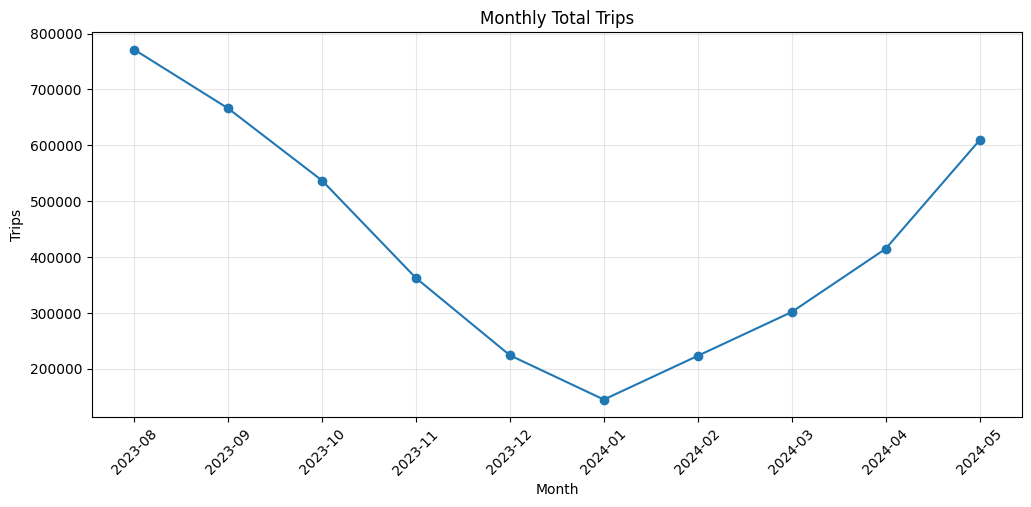

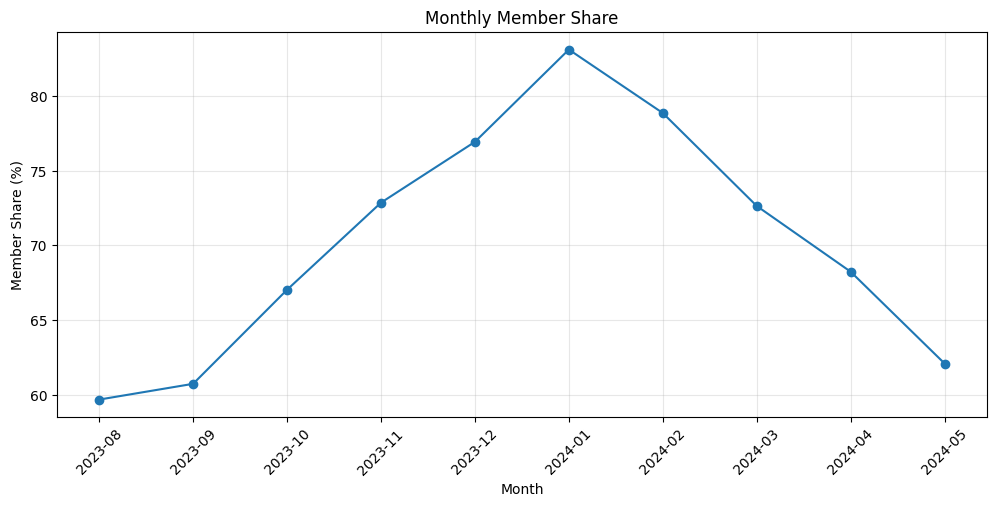


=== TRIPS BY HOUR ===
day_type  Weekday  Weekend
hour                      
0           23442    26142
1           13041    18368
2            7556    11264
3            5450     6277
4            7213     3972
5           29557     4738
6           91105    10463
7          172528    19163
8          211110    34240
9          127226    54273
10         106050    72533
11         130994    85582
12         156506    95641
13         157652    97250
14         161094    98135
15         207023    99752
16         294395    95380
17         353041    86466
18         273173    76498
19         185442    57916
20         127734    41071
21         101613    34529
22          78218    31015
23          49396    23263


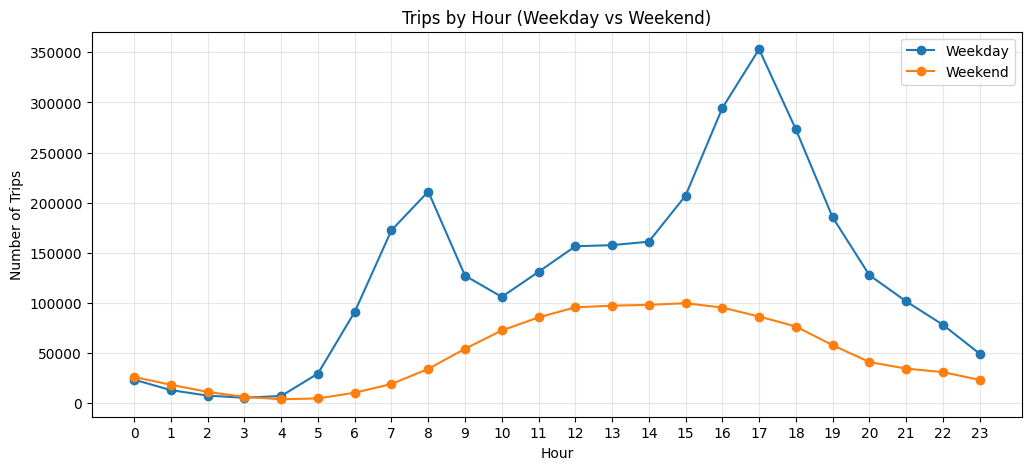


=== TOP 10 START STATION ===
start_station_name
Streeter Dr & Grand Ave              42977
DuSable Lake Shore Dr & Monroe St    28772
Clinton St & Washington Blvd         27333
Kingsbury St & Kinzie St             27189
Clark St & Elm St                    26365
Michigan Ave & Oak St                24675
Wells St & Concord Ln                23298
Clinton St & Madison St              23138
Wells St & Elm St                    22836
University Ave & 57th St             22794
Name: count, dtype: int64


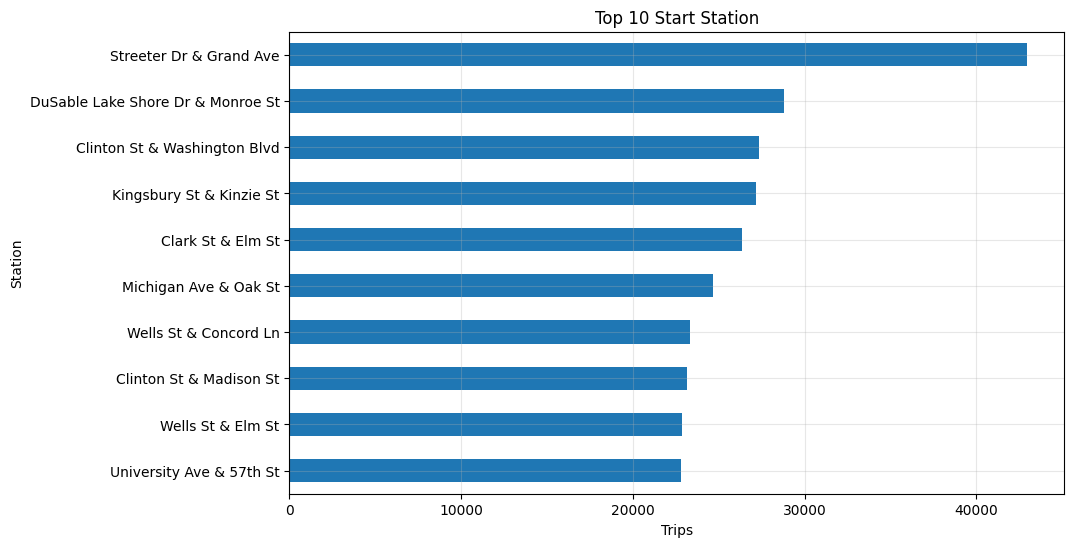


Top 10 Station Concentration: 7.51 %
Missing Start Station Share: 15.64 %

=== KPI MINI TREE ===

KPI UTAMA:
Peak Reliability / Stable Service Index

KPI TURUNAN:
1. Member Share
2. Peak Intensity
3. Top Station Concentration

GUARDRAIL:
Median Trip Duration


=== DECISION STATEMENT ===

Dengan KPI utama Peak Reliability dan guardrail Median Trip Duration,
kami memilih Opsi B — Peak Reliability karena tren menunjukkan volume
perjalanan yang kembali meningkat, pola jam sibuk menunjukkan lonjakan
yang sangat kuat pada weekday pagi dan sore, dan konsentrasi stasiun
menunjukkan adanya hotspot penggunaan yang perlu distabilkan terlebih dahulu.



In [5]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# ======================================
# PATH FOLDER CSV
# ======================================
folder_path = r"C:\Users\ijalg\Documents\vscode\akb\trip"

# ambil semua file csv di folder
files = glob.glob(os.path.join(folder_path, "*.csv"))

print("Jumlah file CSV ditemukan:", len(files))
for f in files:
    print(os.path.basename(f))

# ======================================
# LOAD DATA
# ======================================
df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("\nTotal rows awal:", len(df))

# ======================================
# PREPROCESSING
# ======================================
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"] = pd.to_datetime(df["ended_at"], errors="coerce")

df = df.dropna(subset=["started_at", "ended_at"]).copy()

df["trip_duration"] = (
    df["ended_at"] - df["started_at"]
).dt.total_seconds() / 60

# buang durasi tidak valid
df = df[df["trip_duration"] > 0].copy()

df["month"] = df["started_at"].dt.to_period("M").astype(str)
df["hour"] = df["started_at"].dt.hour
df["weekday"] = df["started_at"].dt.weekday

df["day_type"] = df["weekday"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

df["is_peak"] = df["hour"].isin([7, 8, 9, 16, 17, 18])

print("Total rows setelah cleaning:", len(df))

# ======================================
# KPI METRICS
# ======================================
total_trips = len(df)
member_share = (df["member_casual"] == "member").mean() * 100
ebike_share = (df["rideable_type"] == "electric_bike").mean() * 100
peak_intensity = df["is_peak"].mean() * 100
median_duration = df["trip_duration"].median()

print("\n=== KPI METRICS ===")
print("Total Trips:", total_trips)
print("Member Share:", round(member_share, 2), "%")
print("E-bike Share:", round(ebike_share, 2), "%")
print("Peak Intensity:", round(peak_intensity, 2), "%")
print("Median Trip Duration:", round(median_duration, 2), "minutes")

# ======================================
# OUTPUT 1 - MONTHLY TREND
# ======================================
monthly = df.groupby("month").agg(
    total_trips=("ride_id", "count"),
    member_share=("member_casual", lambda x: (x == "member").mean() * 100)
).reset_index()

# urutkan bulan agar tidak acak
monthly["month_sort"] = pd.to_datetime(monthly["month"])
monthly = monthly.sort_values("month_sort").drop(columns="month_sort")

print("\n=== MONTHLY METRICS ===")
print(monthly)

plt.figure(figsize=(12, 5))
plt.plot(monthly["month"], monthly["total_trips"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Total Trips")
plt.xlabel("Month")
plt.ylabel("Trips")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly["month"], monthly["member_share"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Member Share")
plt.xlabel("Month")
plt.ylabel("Member Share (%)")
plt.grid(True, alpha=0.3)
plt.show()

# ======================================
# OUTPUT 2 - TRIPS BY HOUR
# ======================================
hourly = df.groupby(["hour", "day_type"]).size().unstack(fill_value=0)

# pastikan jam 0-23 selalu ada
hourly = hourly.reindex(range(24), fill_value=0)

print("\n=== TRIPS BY HOUR ===")
print(hourly)

plt.figure(figsize=(12, 5))
for col in hourly.columns:
    plt.plot(hourly.index, hourly[col], marker="o", label=col)

plt.title("Trips by Hour (Weekday vs Weekend)")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ======================================
# OUTPUT 3 - TOP 10 START STATION
# ======================================
top_station = (
    df["start_station_name"]
    .dropna()
    .value_counts()
    .head(10)
)

print("\n=== TOP 10 START STATION ===")
print(top_station)

plt.figure(figsize=(10, 6))
top_station.sort_values().plot(kind="barh")
plt.title("Top 10 Start Station")
plt.xlabel("Trips")
plt.ylabel("Station")
plt.grid(True, alpha=0.3)
plt.show()

# ======================================
# TAMBAHAN: TOP STATION CONCENTRATION
# ======================================
valid_station = df["start_station_name"].dropna()

top10_concentration = (
    valid_station.value_counts().head(10).sum() / len(valid_station) * 100
) if len(valid_station) > 0 else 0

missing_station_share = df["start_station_name"].isna().mean() * 100

print("\nTop 10 Station Concentration:", round(top10_concentration, 2), "%")
print("Missing Start Station Share:", round(missing_station_share, 2), "%")

# ======================================
# KPI MINI TREE
# ======================================
print("\n=== KPI MINI TREE ===")
print("""
KPI UTAMA:
Peak Reliability / Stable Service Index

KPI TURUNAN:
1. Member Share
2. Peak Intensity
3. Top Station Concentration

GUARDRAIL:
Median Trip Duration
""")

# ======================================
# DECISION STATEMENT
# ======================================
print("\n=== DECISION STATEMENT ===")
print("""
Dengan KPI utama Peak Reliability dan guardrail Median Trip Duration,
kami memilih Opsi B — Peak Reliability karena tren menunjukkan volume
perjalanan yang kembali meningkat, pola jam sibuk menunjukkan lonjakan
yang sangat kuat pada weekday pagi dan sore, dan konsentrasi stasiun
menunjukkan adanya hotspot penggunaan yang perlu distabilkan terlebih dahulu.
""")